<a href="https://colab.research.google.com/github/ntu-dl-bootcamp/deep-learning-2026/blob/main/SESSION5/session5_grid.ipynb" target="_blank"><img alt="Open In Colab" src="https://colab.research.google.com/assets/colab-badge.svg"/></a>

# RL Bootcamp (S5): 2D Grid Navigation

The agent moves towards the goal, receiving −10 for falling into a pit and +10 for reaching the goal.

## ❌ **[DO NOT TOUCH]** Installations, Setup and Helpers

In [1]:
# Install stable-baselines2.
%pip install -q gymnasium stable-baselines3 matplotlib 'shimmy>=2.0'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 2.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
SEED = 7
np.random.seed(SEED)

from matplotlib import animation
from IPython.display import HTML

def render_frame(env):
    """Return an RGB image array of the current env state."""
    fig, ax = plt.subplots(figsize=(3, 3))

    canvas = np.ones((env.n, env.n, 3), dtype=np.float32)
    canvas[env.grid == 1] = [0.15, 0.15, 0.15]          # walls
    gr, gc = env.goal
    canvas[gr, gc] = [0.1, 0.75, 0.3]                   # goal

    ax.imshow(canvas, interpolation="nearest")

    ar, ac = env.agent_pos
    ax.scatter(ac, ar, s=180, c="red", edgecolors="white", linewidths=2, zorder=3)

    ax.set_xticks(np.arange(-0.5, env.n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env.n, 1), minor=True)
    ax.grid(which="minor", color="gray", linewidth=0.8)
    ax.set_xticks([]); ax.set_yticks([])

    fig.canvas.draw()
    img = np.asarray(fig.canvas.buffer_rgba())[..., :3]
    plt.close(fig)
    return img


def animate_episode(frames, interval=300):
    """Turn a list of RGB frames into an inline Jupyter animation."""
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.axis("off")
    im = ax.imshow(frames[0])

    def update(i):
        im.set_data(frames[i])
        ax.set_title(f"Step {i}", fontsize=11)
        return [im]

    ani = animation.FuncAnimation(
        fig, update, frames=len(frames), interval=interval, blit=False  # ← blit=False
    )
    html = ani.to_jshtml()   # render before closing
    plt.close(fig)           # close after
    return HTML(html)


# Part 1 [Environment]
---



## ✅ GridWorld4x4 Environment

A **4×4 grid** where an agent navigates from the top-left corner **S_0** to the bottom-right corner **G**, avoiding pits (pits give negative reward but episode continues).

---

### State
The agent's position `(row, col)` where `row, col ∈ {0, 1, 2, 3}`.  
Returned as `np.array([row, col], dtype=float32)`.
```python
spaces.Box(
            low=0.0, high=float(self.n - 1), shape=(2,), dtype=np.float32
        )
```

### Actions
`Discrete(4)` — four cardinal directions:

| Action | Value | Effect |
|--------|-------|--------|
| Up | `0` | row − 1 |
| Down | `1` | row + 1 |
| Left | `2` | col − 1 |
| Right | `3` | col + 1 |
```python
spaces.Discrete(4)
```

### Rewards

| Event | Reward |
|-------|--------|
| Valid move | `0.0` |
| Enter pit or boundary | `−10.0` |
| Reach goal | `+10.0` |

If the agent hits a wall or boundary, it **stays in place**.

### Transition Dynamics

- `0` = free cell, `1` = obstacle
- 4 actions: up, down, left, right
- moving into pit/outside grid: **-10**
- reaching goal: **+10**
- episode ends on goal or max step limit
```python
moves = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
dr, dc = moves[int(action)] # for each action what should be the delta row, delta col
```

### Episode End
- **Terminated** — agent reaches `(3, 3)` ✓
- **Truncated** — agent exceeds `max_steps = 40` without reaching the goal

---

### **Task 1**
Implement the three methods of `GridWorld4x4`:
- `__init__` — define the grid, start/goal positions, action and observation spaces
- `reset` — return the agent to the start position
- `step(action)` — apply movement, compute reward, return `(obs, reward, terminated, truncated, info)`

### **Task 2**
Change reward:
| Event | Reward |
|-------|--------|
| Valid move | `-1.0` |
| Enter pit or boundary | `−10.0` |
| Reach goal | `+10.0` |

### **Task 3**
1. Change the dimension of the grid
2. Change start, goal and pit position


In [3]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces


class GridWorld4x4(gym.Env):
    def __init__(self, max_steps=40):
        super().__init__()

        # Task 3 example: 5x5 grid with new start/goal/pits
        self.grid = np.array([
            [0, 0, 0, 1, 0],
            [0, 1, 0, 0, 0],
            [0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0],
            [1, 0, 0, 0, 0],
        ], dtype=np.int32)

        self.n = self.grid.shape[0]   # grid dimension
        self.start = (0, 0)
        self.goal = (4, 4)
        self.max_steps = max_steps

        # Task 1: action and observation spaces
        self.action_space = spaces.Discrete(4)   # 0=up, 1=down, 2=left, 3=right
        self.observation_space = spaces.Box(
            low=0,
            high=self.n - 1,
            shape=(2,),
            dtype=np.float32
        )

        self.agent_pos = list(self.start)
        self.steps = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # Task 1: reset agent
        self.agent_pos = list(self.start)
        self.steps = 0

        return np.array(self.agent_pos, dtype=np.float32), {}

    def step(self, action):
        self.steps += 1

        moves = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
        dr, dc = moves[int(action)]

        nr = self.agent_pos[0] + dr
        nc = self.agent_pos[1] + dc

        reward = 0.0
        terminated = False

        # Task 2: rewards
        if nr < 0 or nr >= self.n or nc < 0 or nc >= self.n:
            reward = -10.0   # boundary
        elif self.grid[nr, nc] == 1:
            reward = -10.0   # pit
        else:
            self.agent_pos = [nr, nc]
            reward = -1.0    # valid move

        if tuple(self.agent_pos) == self.goal:
            reward = 10.0
            terminated = True

        truncated = self.steps >= self.max_steps

        return (
            np.array(self.agent_pos, dtype=np.float32),
            reward,
            terminated,
            truncated,
            {}
        )

### Test Random Policy

Random Policy: Randomly performs an action.

To take random action use:
```python
env.action_space.sample()
```

To take a step within the environment:
```python
env.step(action)
```

In [4]:
# 1. Initialize Environment
env = GridWorld4x4()

obs, _ = env.reset()
total_reward = 0
frames = [render_frame(env)]

# 2. Loop over environment by taking random action
while True:

    # TODO: take a random action
    action = env.action_space.sample()

    # TODO: take a step in the environment
    # (s,a) -> s'
    obs, reward, terminated, truncated, info = env.step(action)

    total_reward += reward
    frames.append(render_frame(env))

    if terminated or truncated:
        break

print(f"Total reward: {total_reward} | Total steps: {env.steps}")

Total reward: -229.0 | Total steps: 40


### Vizualize Random Policy

In [5]:
animate_episode(frames, interval=300)



---



# Part 2 [DQN]


---



In [6]:
# imports and helper code
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback

SEED = 42

# Helper: Callback to record episode rewards during training ---
class RewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self._current_reward = 0.0

    def _on_step(self) -> bool:
        self._current_reward += self.locals["rewards"][0]
        if self.locals["dones"][0]:
            self.episode_rewards.append(self._current_reward)
            self._current_reward = 0.0
        return True
callback = RewardCallback() # this is to store reward for plotting

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Using StableBaselines3 (DQN)

In this section, we use sb3 library to solve the above problem of learning navigation in grid.

DQN has several hyperparameters that control **how** the agent learns. The most important ones are:

- **`learning_rate`** — how large each gradient update step is. Too high causes unstable training; too low makes learning slow.
- **`buffer_size`** — the replay buffer stores past experience `(s, a, r, s')`. Sampling randomly from this buffer breaks the correlation between consecutive transitions, which stabilises training.
- **`learning_starts`** — training only begins after this many steps, ensuring the buffer has enough diverse experience before the first gradient update.
- **`batch_size`** — number of transitions sampled from the buffer per update. Larger batches give more stable gradient estimates.
- **`gamma`** — the discount factor. A value close to 1 makes the agent care about long-term rewards; a lower value prioritises immediate rewards.
- **`train_freq`** — how often the network is updated. Updating too frequently relative to new experience collected can overfit to recent transitions.
- **`target_update_interval`** — DQN uses two networks: an online network (updated every step) and a target network (updated every N steps). The target network provides stable Q-value targets and prevents oscillation.
- **`exploration_fraction` / `exploration_final_eps`** — DQN explores using ε-greedy: with probability ε it picks a random action. ε decays from 1.0 to `exploration_final_eps` over `exploration_fraction` of total training steps.

Training an RL agent with Stable Baselines3 follows three steps:

### 1. Initialise the Environment
```python
env = GridWorld4x4(max_steps=40)
```
The environment defines the problem — states, actions, rewards, and episode termination. SB3 expects the environment to follow the Gymnasium interface (`reset`, `step`).

### 2. Initialise the Model
```python
model = DQN(
    "MlpPolicy",
    env,
    learning_rate=?,        # step size for the Adam optimizer
    buffer_size=10_000,        # replay buffer capacity; stores past (s, a, r, s') transitions
    learning_starts=5000,       # number of steps to collect before training begins
    batch_size=128,             # number of transitions sampled per gradient update
    gamma=0.95,                # discount factor; how much future rewards are valued
    train_freq=16,              # update the network every 4 environment steps
    target_update_interval=500,# steps between copying online network weights to target network
    exploration_fraction=0.5,  # fraction of training spent decaying epsilon (explore → exploit)
    exploration_final_eps=0.01,# minimum epsilon; agent still acts randomly 5% of the time
    verbose=1,                 # 0 = silent, 1 = training info
    seed=SEED,
)
```
This creates the DQN agent. `"MlpPolicy"` tells SB3 to use a **Multi-Layer Perceptron** as the Q-network — a simple fully connected neural network that takes the state `(row, col)` as input and outputs a Q-value for each of the 4 actions. The default architecture is two hidden layers of 64 units each with ReLU activations:

The output neuron with the highest Q-value is selected as the action.

### 3. Train
```python
model.learn(total_timesteps=40_000, callback=callback)
```
SB3 runs the training loop automatically. At each timestep the agent:
1. Observes the current state
2. Picks an action (random with probability ε, greedy otherwise)
3. Stores the transition `(s, a, r, s')` in the replay buffer
4. Samples a batch from the buffer and updates the Q-network

This repeats for `total_timesteps` steps across many episodes.

In [7]:
# 1. Initialize Environment
env = GridWorld4x4(max_steps=40)

# 2. Initialize the RL method
model = DQN(
    "MlpPolicy",
    env,
    learning_rate=1e-3,
    buffer_size=10_000,
    learning_starts=5000,
    batch_size=128,
    gamma=0.95,
    train_freq=16,
    target_update_interval=500,
    exploration_fraction=0.5,
    exploration_final_eps=0.01,
    verbose=1,
    seed=SEED,
)

# 3. Train the model
model.learn(total_timesteps=40_000, callback=callback)

print(f"Training done. Episodes: {len(callback.episode_rewards)}")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 38.5     |
|    ep_rew_mean      | -144     |
|    exploration_rate | 0.992    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 9254     |
|    time_elapsed     | 0        |
|    total_timesteps  | 154      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 36.1     |
|    ep_rew_mean      | -152     |
|    exploration_rate | 0.986    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 8137     |
|    time_elapsed     | 0        |
|    total_timesteps  | 289      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 34.5     |
|    ep_rew_mean      | -143   

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 38.2     |
|    ep_rew_mean      | -171     |
|    exploration_rate | 0.924    |
| time/               |          |
|    episodes         | 40       |
|    fps              | 6366     |
|    time_elapsed     | 0        |
|    total_timesteps  | 1530     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 38.4     |
|    ep_rew_mean      | -172     |
|    exploration_rate | 0.916    |
| time/               |          |
|    episodes         | 44       |
|    fps              | 6492     |
|    time_elapsed     | 0        |
|    total_timesteps  | 1690     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 38.3     |
|    ep_rew_mean      | -170     |
|    exploration_rate | 0.909    |
| time/               |          |
|    episodes       

### Reward Plot

We show the smoothened version of the reward plot (academic standard)

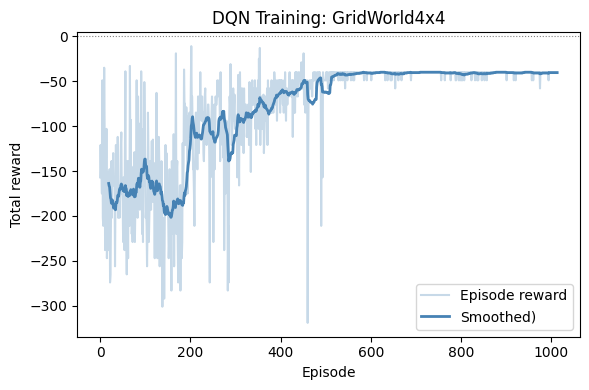

In [8]:
# --- Plot ---
rewards = np.array(callback.episode_rewards)
window = 20
smoothed = np.convolve(rewards, np.ones(window) / window, mode="valid")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rewards, alpha=0.3, color="steelblue", label="Episode reward")
ax.plot(range(window - 1, len(rewards)), smoothed, color="steelblue", linewidth=2, label=f"Smoothed)")
ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
ax.set_xlabel("Episode")
ax.set_ylabel("Total reward")
ax.set_title("DQN Training: GridWorld4x4")
ax.legend()
plt.tight_layout()
plt.show()

## Evaluate the trained agent

Use following to get action from the trained model:
```python
model.predict(obs, deterministic=True)
```

In [9]:
obs, _ = env.reset()
total_reward = 0
frames = [render_frame(env)]

while True:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward

    frames.append(render_frame(env))
    if terminated or truncated:
        break

print(f"Total reward: {total_reward} | Total steps: {env.steps}")

Total reward: -40.0 | Total steps: 40


In [10]:
# view agent performing the actions
animate_episode(frames, interval=300)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Part 3 [PPO]


---


## Using PPO

Read stablebaselines3 module: https://stable-baselines3.readthedocs.io/en/master/modules/ppo.html

Use the following model
```python
model = PPO(
    "MlpPolicy",
    env,
    learning_rate=3e-4,        # step size for the Adam optimizer
    n_steps=512,               # steps collected per environment before each update
    batch_size=64,             # minibatch size for gradient updates
    n_epochs=10,               # number of passes over collected rollout data per update
    gamma=0.95,                # discount factor; how much future rewards are valued
    gae_lambda=0.95,           # GAE smoothing; trades off bias vs variance in advantage estimates
    clip_range=0.2,            # PPO clip parameter; limits how much the policy can change per update
    ent_coef=0.01,             # entropy bonus; encourages exploration throughout training
    verbose=1,                 # 0 = silent, 1 = training info
    seed=SEED,
)
```

In [11]:
from stable_baselines3 import PPO

callback = RewardCallback()

# 1. Initialize the environment
env = GridWorld4x4(max_steps=40)

# 2. Initialize RL algorithm
model = PPO(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    n_steps=512,
    batch_size=64,
    n_epochs=10,
    gamma=0.95,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    verbose=1,
    seed=SEED,
)

# 3. Train
model.learn(total_timesteps=40_000, callback=callback)
print(f"Training done. Episodes: {len(callback.episode_rewards)}")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 40       |
|    ep_rew_mean     | -172     |
| time/              |          |
|    fps             | 1461     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 512      |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 39.1         |
|    ep_rew_mean          | -163         |
| time/                   |              |
|    fps                  | 1076         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 1024         |
| train/                  |              |
|    approx_kl            | 0.0073338854 |
|    clip_fraction        | 0.0264       |
|    clip_range           | 0.2          |
|    en

In [12]:
obs, _ = env.reset()
total_reward = 0
frames = [render_frame(env)]

while True:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward

    frames.append(render_frame(env))
    if terminated or truncated:
        break

print(f"Total reward: {total_reward} | Total steps: {env.steps}")

Total reward: 3.0 | Total steps: 8


In [13]:
# view agent performing the actions
animate_episode(frames, interval=300)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Done!